In [1]:
# ==========================================
# IMPORTS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_csv("features.csv")

df.head()

,Unnamed: 0,id_student,login_frequency,total_clicks,activity_std,submission_delay,avg_score,study_status,withdrawal_status,gender,region,highest_education,imd_band,age_band
0,0,6516,3310,13955,72.511987,-2.600000,61.800000,finished,didn't withdraw,M,Scotland,HE Qualification,80-90%,55<=
1,1,8462,916,1978,28.877376,-18.538462,87.307692,unfinished,late withdrawal,M,London Region,HE Qualification,30-40%,55<=
2,2,11391,980,4670,72.690368,-1.800000,82.000000,finished,didn't withdraw,M,East Anglian Region,HE Qualification,90-100%,55<=
3,3,23629,236,644,25.581397,3.500000,82.500000,finished,didn't withdraw,F,East Anglian Region,Lower Than A Level,20-30%,0-35
4,4,23698,2440,7280,70.811958,1.125000,73.750000,finished,didn't withdraw,F,East Anglian Region,A Level or Equivalent,50-60%,0-35


In [2]:
print(df.dtypes)

Unnamed: 0             int64
id_student             int64
login_frequency        int64
total_clicks           int64
activity_std         float64
submission_delay     float64
avg_score            float64
study_status          object
withdrawal_status     object
gender                object
region                object
highest_education     object
imd_band              object
age_band              object
dtype: object


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [4]:
print(df.dtypes)

Unnamed: 0             int64
id_student             int64
login_frequency        int64
total_clicks           int64
activity_std         float64
submission_delay     float64
avg_score            float64
study_status           int32
withdrawal_status      int32
gender                 int32
region                 int32
highest_education      int32
imd_band               int32
age_band               int32
dtype: object


In [5]:
# Remove unwanted column
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# Handle missing values
df.fillna(0, inplace=True)

# Prepare X
X = df.drop('id_student', axis=1, errors='ignore')

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.26848746 0.14374807]


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23343 entries, 0 to 23342
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         23343 non-null  int64  
 1   login_frequency    23343 non-null  int64  
 2   total_clicks       23343 non-null  int64  
 3   activity_std       23343 non-null  float64
 4   submission_delay   23343 non-null  float64
 5   avg_score          23343 non-null  float64
 6   study_status       23343 non-null  int32  
 7   withdrawal_status  23343 non-null  int32  
 8   gender             23343 non-null  int32  
 9   region             23343 non-null  int32  
 10  highest_education  23343 non-null  int32  
 11  imd_band           23343 non-null  int32  
 12  age_band           23343 non-null  int32  
dtypes: float64(3), int32(7), int64(3)
memory usage: 1.7 MB


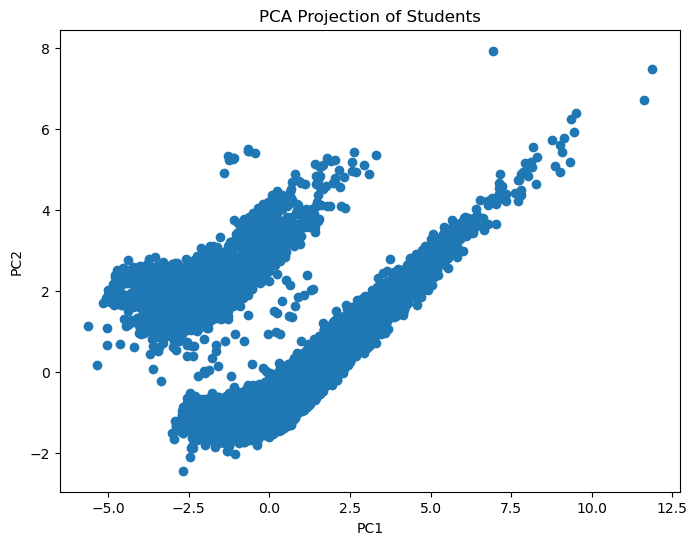

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Projection of Students")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

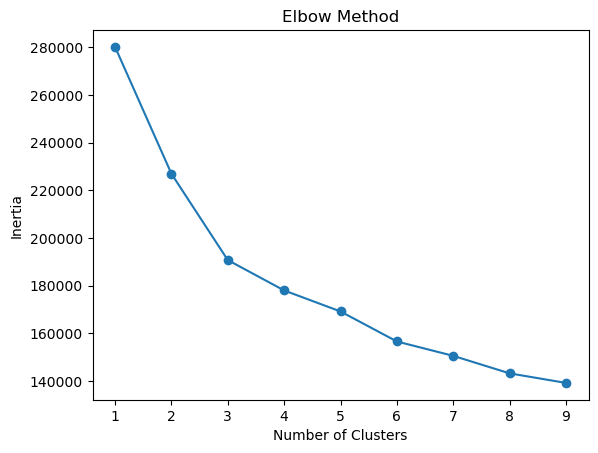

In [9]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

df['cluster_kmeans'] = labels_kmeans

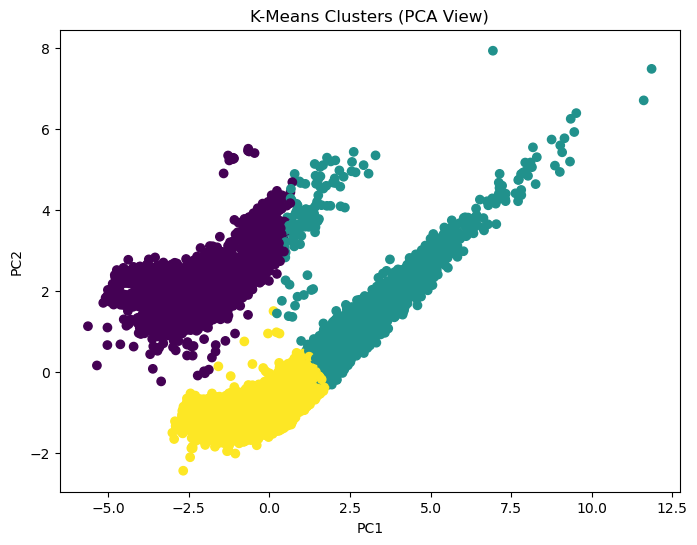

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans)
plt.title("K-Means Clusters (PCA View)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

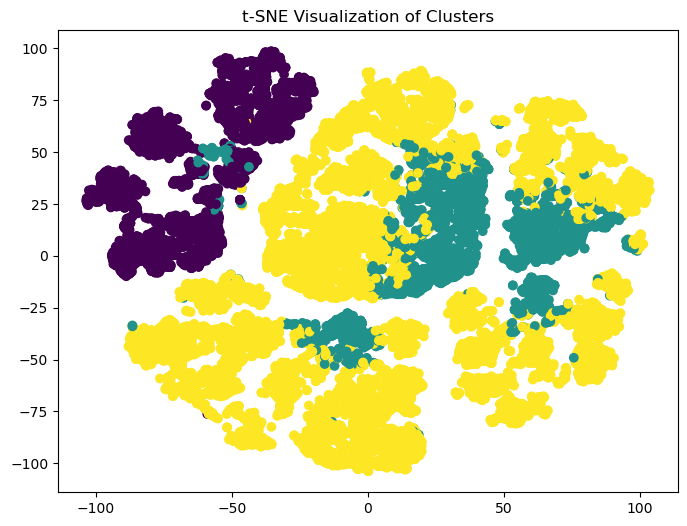

In [25]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels_kmeans)
plt.title("t-SNE Visualization of Clusters")
plt.show()

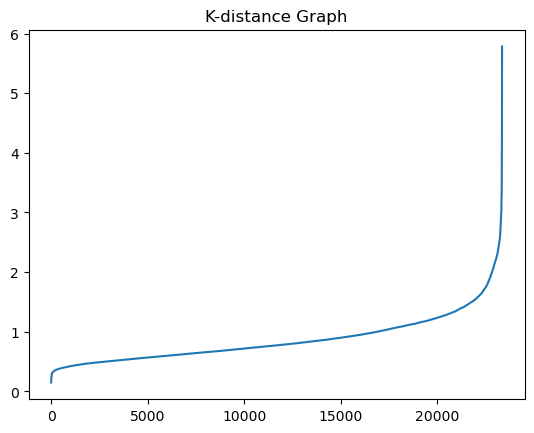

In [39]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])
plt.plot(distances)
plt.title("K-distance Graph")
plt.show()

In [40]:
dbscan = DBSCAN(eps=1.7, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

df['cluster_dbscan'] = labels_db

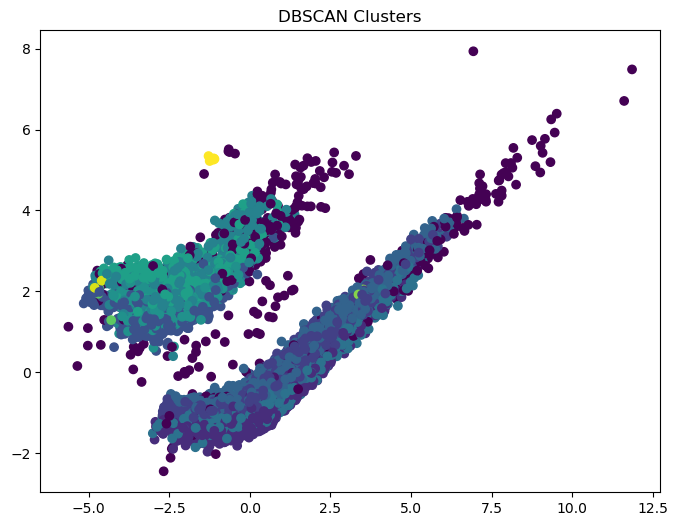

In [41]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db)
plt.title("DBSCAN Clusters")
plt.show()

In [15]:
cluster_summary = df.groupby('cluster_kmeans').mean()
cluster_summary

,id_student,login_frequency,total_clicks,activity_std,submission_delay,avg_score,study_status,withdrawal_status,gender,region,highest_education,imd_band,age_band,cluster_dbscan
cluster_kmeans,,,,,,,,,,,,,,
0,711261.139159,1124.196628,3806.383519,32.381035,-9.291466,65.431728,0.999763,2.299691,0.566611,5.953930,1.079079,3.952980,0.289242,9.563287
1,728331.277989,11754.356182,51276.124143,76.731409,-43.659468,80.661741,0.024372,0.051282,0.782940,5.656258,0.962427,4.333841,0.362021,5.149023
2,703695.632331,2425.086882,7826.983611,56.145816,-5.202905,73.438273,0.000263,0.000132,0.452840,5.929310,0.972487,4.248667,0.310604,5.353584
